# Simon's Algorithm

In [61]:
import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [62]:
# Simon's algorithm for n=3
# Build a 2-to-1 oracle for a secret s (3-bit) and run Simon's algorithm 3 times

import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

n = 2  # number of input bits

# Choose a secret s (non-zero). You can set this explicitly if you want reproducible runs.
# For demonstration we'll choose a random non-zero s and print it (you can remove the print to keep it secret).
s = random.choice([i for i in range(1, 2**n)])
print(f"Secret s (binary): {s:0{n}b}")

# Build a 2-to-1 function mapping: map each x and x^s to the same output label
mapping = {}
next_label = 0
for x in range(2**n):
    if x in mapping:
        continue
    y = next_label
    mapping[x] = y
    mapping[x ^ s] = y
    next_label += 1

print('mapping', mapping)


Secret s (binary): 11
mapping {0: 0, 3: 0, 1: 1, 2: 1}


In [63]:
# We'll represent outputs y as n-bit numbers (you can shrink output width, but keeping n bits simplifies the reversible implementation)
# Build an oracle that maps |x>|0> -> |x>|f(x)>
num_qubits = n + n  # input qubits + output qubits
oracle = QuantumCircuit(num_qubits, name='SimonOracle')

In [64]:
# helper to apply multi-controlled X (try mcx then mct)
def mcx_safe(qc, controls, target):
    try:
        qc.mcx(controls, target)
    except Exception:
        # some qiskit versions use 'mct'
        qc.mct(controls, target)

In [65]:
# For each input x, set the output register to mapping[x] using multi-controlled X gates
for x in range(2**n):
    y = mapping[x]
    y_bits = [(y >> i) & 1 for i in range(n)]  # lsb first
    controls = list(range(n))  # input qubits are 0..n-1

    # For each output bit that should be 1, apply an MCX controlled on input==x to flip the corresponding output qubit
    for i, bit in enumerate(y_bits):
        if bit == 0:
            continue

        # Prepare controls so that they are 1 when input == x
        # For input bit j where x_j == 0, apply X to flip it (so control sees a 1)
        flip_positions = [j for j in range(n) if ((x >> j) & 1) == 0]
        for j in flip_positions:
            oracle.x(j)

        # apply MCX: controls are input qubits (0..n-1), target is output qubit n+i
        mcx_safe(oracle, controls, n + i)

        # undo the flips
        for j in flip_positions:
            oracle.x(j)

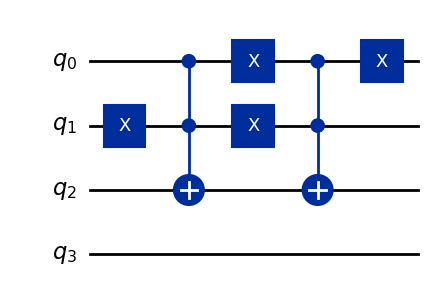

In [66]:
oracle.draw('mpl')

In [67]:
# Convert the oracle circuit into a gate
SimonOracle = oracle.to_gate()
SimonOracle.label = 'U_f'

# Build Simon circuit: input register (0..n-1), output register (n..2n-1)
qc = QuantumCircuit(num_qubits, n)  # measure only input register

In [68]:
# 1) Prepare input in superposition
qc.h(range(n))

# 2) Oracle
qc.append(SimonOracle, list(range(num_qubits)))

# 3) Apply H again to input qubits
qc.h(range(n))

# 4) Measure input qubits
qc.measure(range(n), list(range(n)))

# Show the circuit
print(qc.draw())

     ┌───┐┌──────┐┌───┐┌─┐   
q_0: ┤ H ├┤0     ├┤ H ├┤M├───
     ├───┤│      │├───┤└╥┘┌─┐
q_1: ┤ H ├┤1     ├┤ H ├─╫─┤M├
     └───┘│  U_f │└───┘ ║ └╥┘
q_2: ─────┤2     ├──────╫──╫─
          │      │      ║  ║ 
q_3: ─────┤3     ├──────╫──╫─
          └──────┘      ║  ║ 
c: 2/═══════════════════╩══╩═
                        0  1 


In [69]:
# Simulate the circuit n times (shots=n) to get n sample z's
sim = AerSimulator()
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=n)
result = job.result()
# expand counts into a list of bitstrings (LSB on the right as qiskit returns)
counts = result.get_counts()
print('Raw counts:', counts)

# Expand counts into individual samples (bitstrings)
samples = []
for bitstr, c in counts.items():
    # Qiskit returns bitstrings with qubit 0 as right-most char; reverse to have msb..lsb order consistent with our integer conversion
    for _ in range(c):
        samples.append(bitstr)

print('Measured z strings (qubit order printed as returned by Qiskit):', samples)

Raw counts: {'11': 2}
Measured z strings (qubit order printed as returned by Qiskit): ['11', '11']


In [70]:
# Convert bitstrings to integer z values (we'll interpret the bitstring as returned by Qiskit: qubit 0 is the rightmost char)
def bitstr_to_int(bitstr):
    # bitstr e.g. '010' where index 0 is qubit 2 and index -1 is qubit 0
    # Convert to integer where bit 0 is lsb
    return int(bitstr[::-1], 2)

z_values = [bitstr_to_int(b) for b in samples]
print('z values (as integers, lsb=bit0):', z_values)

z values (as integers, lsb=bit0): [3, 3]


In [71]:
# Solve for s by brute force: find non-zero s in 1..2^n-1 such that z.s = 0 (mod 2) for all measured z's
candidates = []
for cand in range(1, 2**n):
    ok = True
    for z in z_values:
        # dot product mod 2
        dot = bin(z & cand).count('1') % 2
        if dot != 0:
            ok = False
            break
    if ok:
        candidates.append(cand)

print('Candidates for s (binary):', [f"{c:0{n}b}" for c in candidates])

Candidates for s (binary): ['11']


In [72]:
# If unique candidate found, that's s. Otherwise more samples are needed.
if len(candidates) == 1:
    found_s = candidates[0]
    print(f"Recovered s: {found_s:0{n}b}")
else:
    print('Could not uniquely determine s from 3 samples; need more independent z measurements.')
    if len(candidates) > 0:
        print('Possible s values:', [f"{c:0{n}b}" for c in candidates])

# For verification (optional) print the actual s chosen earlier
print('Actual secret s (for verification):', f"{s:0{n}b}")

Recovered s: 11
Actual secret s (for verification): 11
